# Candidate rewrite selection

**Recipe 13** · Level 2 (Easy) · Decision type: `Choice`

Choose a supplied sentence rewrite that preserves the original meaning and requested tone, with a no-suitable-rewrite outcome when necessary.

Sources:

- S02: [TypeSafe AI: Primitives (Questions)](https://docs.typesafe.ai/primitives)
- S03: [TypeSafe AI: Confidence](https://docs.typesafe.ai/confidence)
- S07: [TypeSafe AI: Jev 1.13 jaggedness](https://docs.typesafe.ai/model-jaggedness/jev-1.13)

## What you will build

A small rewrite-selection assistant for a tone-adjustment tool. Three candidate rewrites of one sentence are generated ahead of time by ordinary Python -- fixed, fabricated text, never by calling a text model -- and Jev reads the original sentence, the requested tone, and the three candidates, then picks exactly one of four options: `candidate_1`, `candidate_2`, `candidate_3`, or the explicit fallback `no_suitable_rewrite` the use case names for when none of the three both preserves the original's meaning and matches the requested tone. Python owns everything else: which candidate sits at which position, the rule that returns a confident candidate's own text, keeps the original sentence unchanged whenever Jev says no candidate fits (whatever its confidence), and sends anything else uncertain to an explicit `review` outcome instead of guessing. By the end you will have looked at individual typed answers across the full range of confidence -- including one that is wrong and one that is held back for review -- seen the rule that acts on them, and run an evaluation that chooses its one setting on `validation` and reports top-1 accuracy, `no_suitable_rewrite`'s own precision and recall, and a selective coverage, accuracy and risk computed from what the rule actually did, over this recipe's 40 stored answers (19 `validation`, 19 `test`, 2 `demo`).

## Setup and run mode

The notebook runs from its own folder with the standard library and `jev_cookbook` only. `get_backend(fixtures=...)` replays the 40 stored answers in `fixtures/responses.json` offline; setting `JEV_COOKBOOK_LIVE=1` (see the README) swaps in live calls to the same question definition and changes nothing else. `run_header` states which mode ran, and every number below carries that mode with it.

In [1]:
from jev_cookbook import get_backend, load_helpers
from jev_cookbook.evaluation import (
    accuracy,
    confusion_matrix,
    evaluate_outcomes,
    evaluate_selective,
    per_class_metrics,
    select_confidence_threshold,
    selective_curve,
)
from jev_cookbook.fixtures import load_inputs, load_labels, responses_path, select_split
from jev_cookbook.style import (
    apply_style,
    plot_answer_probabilities,
    plot_confusion_matrix,
    plot_risk_coverage,
    run_header,
    show_answer,
)

apply_style()
helpers = load_helpers()  # this recipe's helpers.py, loaded by path
examples = load_inputs()
labels = load_labels()
backend = get_backend(fixtures=responses_path())
questions = helpers.build_questions()
# N for the header is the number of examples the metrics are about: validation and test. This
# recipe has no train split; demo examples are shown but never scored.
scored = [e for e in examples if e.split not in ("train", "demo")]

offline = backend.mode in ("synthetic", "scripted")
check = " (a pipeline check, not a Jev result)" if offline else ""
# CONTRIBUTING.md section 2: a number from the validation split is a selection step, not a
# result. This label does not depend on the run mode, unlike `check` above: even a recorded or
# live run must not print a bare validation number. A synthetic or scripted run prints both
# labels on a validation number (`{selection}{check}`): it is still a pipeline check too.
selection = " (a selection step, not a reported result)"

# Every one of the 40 examples in fixtures/ needs at most one request. This cache makes sure an
# item that is shown individually and later scored in its split is decided once, so the whole
# notebook makes exactly 40 requests in live mode, never more.
answered = {}


def decide(example):
    if example.id not in answered:
        answered[example.id] = backend.decide(helpers.build_state(example.fields), questions)[
            "rewrite"
        ]
    return answered[example.id]


run_header(13, "Candidate rewrite selection", backend=backend, n_examples=len(scored))

Recipe 13: Candidate rewrite selection
Mode: offline replay of synthetic fixtures, pipeline check on a fixture sample of 38 examples
Metrics in this run are checks that the pipeline works. They are not Jev results.


## The state

The state is everything Jev sees, and Python builds it. Each example in `fixtures/inputs.jsonl` carries `fields`: an `item_id`, the `original` sentence, the `requested_tone`, and a tuple of three `candidates`. `build_state` assigns the three candidates to the fixed positions `candidate_1`, `candidate_2` and `candidate_3` and passes on the original sentence and the requested tone; the `item_id` stays in Python and is attached to the outcome at the end, so it never passes through the model.

In [2]:
import json

demo = {e.id: e for e in examples if e.split == "demo"}
example = demo["d01-renewal-date"]
print("Python has:")
print(json.dumps(example.fields, indent=2))
state = helpers.build_state(example.fields)
print("Jev sees:")
print(json.dumps(state, indent=2))

Python has:
{
  "item_id": "R3001",
  "original": "We're moving your renewal date up by two weeks.",
  "requested_tone": "friendly",
  "candidates": [
    "Your renewal date has been moved up by two weeks.",
    "Quick heads-up -- we've shifted your renewal date up by two weeks, just wanted you to know!",
    "We're moving your renewal date back by two weeks."
  ]
}
Jev sees:
{
  "original": "We're moving your renewal date up by two weeks.",
  "requested_tone": "friendly",
  "candidate_1": "Your renewal date has been moved up by two weeks.",
  "candidate_2": "Quick heads-up -- we've shifted your renewal date up by two weeks, just wanted you to know!",
  "candidate_3": "We're moving your renewal date back by two weeks."
}


## The questions

There is one question, and it asks one thing: which of the three candidate rewrites, if any, both keeps the original sentence's meaning and matches the requested tone? A `Choice` fits because the outcomes are exclusive and Jev should commit to exactly one ([S02](https://docs.typesafe.ai/primitives) describes `Choice` as picking exactly one option from a fixed, known set with no inherent order). Three of the four options are the candidate identifiers; Python assigns which rewrite sits at which position and holds each candidate's own text, and returns that text unchanged for a confident match -- the model never writes a rewrite, only picks among the three it is given. The fourth, `no_suitable_rewrite`, is the explicit fallback the use case names for an item where none of the three candidates resolves the task; choosing it means keeping the original sentence exactly as written.

**Fixed positions, not fixed content.** `candidate_1`, `candidate_2` and `candidate_3` always name the same three positions, but which rewrite -- the faithful one, or one that changes the meaning, misses the tone, or both -- sits at which position varies from one item to the next, deliberately (see `build_fixtures.py`). [backends.md](../../docs/backends.md#replay-key) notes that a `Choice`'s option *order* is part of its replay key, and [S07](https://docs.typesafe.ai/model-jaggedness/jev-1.13) (item 8) documents that jev-1.13 leans toward whichever option comes first. Reordering the options themselves on every request would change the replay key each time and make nothing replayable offline; this recipe instead fixes the option order (`candidate_1`, `candidate_2`, `candidate_3`, `no_suitable_rewrite`, every time) and varies which candidate occupies the first position across the fixture set, so that a model with S07's lean cannot simply win by always picking first: here, the correct candidate sits at every one of the three positions across different items, and several items have no correct candidate at all.

Each candidate's description below is the same three sentences with only the position's name substituted, because there is nothing else to say about a position ahead of time -- what belongs to it changes with every item. The fallback's description instead says what sends an item to it: none of the three candidates both preserving the meaning and matching the tone.

In [3]:
rewrite = questions["rewrite"]
print(rewrite.instructions)
for name, description in rewrite.criteria.items():
    print(f"  {name:20s} {description}")

The state gives the original sentence, the requested tone, and three candidate rewrites of it under candidate_1, candidate_2 and candidate_3. Choose the identifier of the one candidate that both keeps the original sentence's meaning intact and matches the requested tone. If none of the three candidates does both, choose no_suitable_rewrite instead of picking the closest wrong one.
  candidate_1          The text under 'candidate_1' in the state is a faithful rewrite of the original sentence: it keeps every fact, request and commitment the original makes, changing none of them, and its tone matches the requested tone. A rewrite that changes what the original says, or that reads in a different tone than the one requested, does not belong to this option even if it is otherwise well written -- it belongs to no_suitable_rewrite instead, together with the other two candidates, unless one of the other two candidates is the faithful, correctly toned one.
  candidate_2          The text under '

## One answer up close

Before any aggregate number, look at three typed answers across the range this recipe covers: an item where two candidates both keep the meaning and the choice comes down to which one actually reads in the requested tone, an item where no candidate fits at all, and an item in `validation` whose stored answer is simply wrong. Each answer holds the chosen option, a probability for every option, a `confidence` and a `provenance` line that says where the answer came from, here always `synthetic`, since nothing in this recipe's fixtures came from a real call. `confidence` for a `Choice` with 4 options is the top probability rescaled, `(p_max - 1/4) / (1 - 1/4)` ([S03](https://docs.typesafe.ai/confidence)): 0 when the top option holds no more than a quarter of the probability, 1 when one option holds all of it. These three come from the `demo` and `validation` splits only; `test` is reported once, after every choice below is frozen, not peeked at here.

Choice: candidate_2 (confidence 0.23)
  candidate_2          0.42  ########
  candidate_1          0.35  #######
  candidate_3          0.11  ##
  no_suitable_rewrite  0.11  ##
Provenance: synthetic


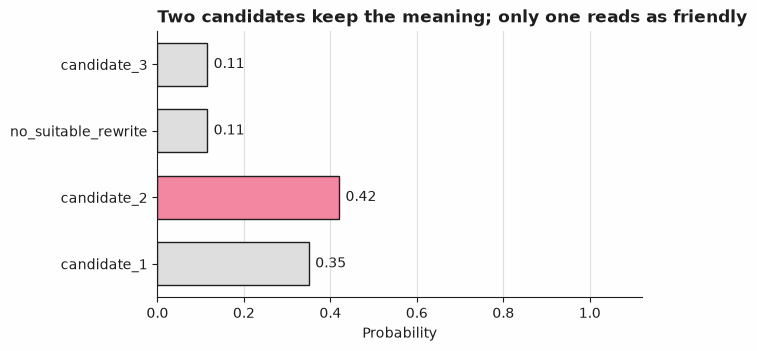

In [4]:
ambiguous_example = demo["d01-renewal-date"]
ambiguous_answer = decide(ambiguous_example)
show_answer(ambiguous_answer)
plot_answer_probabilities(
    ambiguous_answer, title="Two candidates keep the meaning; only one reads as friendly"
)

Both `candidate_1` ("Your renewal date has been moved up by two weeks.") and `candidate_2` ("Quick heads-up -- we've shifted your renewal date up by two weeks, just wanted you to know!") state the same fact as the original sentence; the requested tone is `friendly`, and only `candidate_2` actually reads that way, so the stored answer puts it only just ahead of `candidate_1`, 0.42 against 0.35, for a `confidence` of 0.23: `(0.42 - 1/4) / (3/4)`. [Gold label](../../docs/glossary.md#gold-label) below means the correct answer written down in `labels.jsonl` before this notebook ever runs, decided in advance from the rule each option's description states, not from the model; this particular row is a `demo` example and carries no gold label at all (no `demo` example in this recipe does), so there is nothing to score it against here -- its purpose is to show the probabilities, not to be marked right or wrong.

**The acceptable set is a singleton by construction.** Every scored row is written so that at most one candidate both preserves the meaning and matches the tone -- never two -- and when none does, the gold label is `no_suitable_rewrite` instead; comparing Jev's single `choice` against the single gold id is therefore comparing one acceptable set against another, not quietly discarding an equally-right alternative. `v19-admin-access` later in `validation` is the row that makes this worth saying out loud: two candidates are both arguably "firm but polite" there, and the gold label picks the warmer of the two on purpose, not by elimination.

In [5]:
nosuitable_example = demo["d02-custom-integrations"]
nosuitable_answer = decide(nosuitable_example)
show_answer(nosuitable_answer)

Choice: no_suitable_rewrite (confidence 0.44)
  no_suitable_rewrite  0.58  ############
  candidate_1          0.15  ###
  candidate_2          0.14  ###
  candidate_3          0.14  ###
Provenance: synthetic


None of the three candidates for this item both keeps the meaning and matches the requested `encouraging` tone: one reverses what the original says, one is flatly discouraging, and one overgeneralizes into a dismissal. The stored answer was written to agree, putting `no_suitable_rewrite` clearly ahead at 0.58, with `candidate_1` the only real runner-up at 0.15 -- a hand-written probability, not evidence the model produced; the point of this example is to show what the fields mean, not to demonstrate that Jev gets it right. `no_suitable_rewrite`'s `confidence`, 0.44, matters for how this answer reads but not for what Python does with it: `select_rewrite`, below, keeps the original sentence unchanged whenever Jev names `no_suitable_rewrite`, whatever its confidence -- there is no candidate's rewritten text a confidence check could protect here, only the sentence as already written.

In [6]:
wrong_example = next(e for e in examples if e.id == "v06-sympathetic-wrong")
wrong_answer = decide(wrong_example)
print(wrong_example.fields["original"], "->", wrong_example.fields["requested_tone"])
show_answer(wrong_answer)

We can't approve the refund as requested. -> sympathetic
Choice: candidate_1 (confidence 0.27)
  candidate_1          0.45  #########
  candidate_3          0.30  ######
  candidate_2          0.12  ##
  no_suitable_rewrite  0.12  ##
Provenance: synthetic


The gold label here (written down in `labels.jsonl`, not produced by Jev) is `candidate_3`: "I know this isn't the answer you were hoping for, and I'm sorry -- we're not able to approve the refund as requested" is the one rewrite that actually reads as `sympathetic`, the requested tone. `candidate_1`, "We're unable to approve the refund as requested," keeps the meaning exactly but reads flat and neutral, not sympathetic -- and the stored answer gets this wrong, naming `candidate_1` at 0.45 against `candidate_3`'s 0.30, a `confidence` of 0.27. This is the one wrong answer this recipe places in `validation` itself, on purpose: without it, every real-candidate answer in `validation` would be correct, and the threshold chosen two cells below would have nothing to cut on (it would come back as whatever the lowest observed confidence happens to be, whatever accuracy target is asked for). With it, the threshold has a real wrong answer to exclude, and -- as the next section shows -- it does exclude this one.

## Python's part

Jev supplies the judgment; what happens with it is code. `select_rewrite` in `helpers.py` returns a confident candidate's own text, keeps the original sentence unchanged as a final `no_suitable_rewrite` result whatever its confidence (choosing it already means nothing is being rewritten, so there is no stored candidate text a confidence check could protect), and sends anything else below the confidence gate to an explicit `review` outcome instead of returning a possibly wrong rewrite. `tests/test_helpers.py` checks the rule at the boundary, outside `0` to `1`, for a confident and a low-confidence answer at every one of the three candidate positions, and for `no_suitable_rewrite` at both a high and a low confidence, so a rule that quietly exempted one position from the gate, or started gating `no_suitable_rewrite` on confidence after all, would fail it.

The confidence gate itself is chosen here, on `validation`, and then frozen for the rest of this notebook: `select_confidence_threshold` picks the lowest value whose answered subset is perfectly accurate, over the `validation` items Jev actually matched to one of the three candidates (the ones it called `no_suitable_rewrite` are excluded from this selection on purpose -- `select_rewrite` never applies the gate to them, so feeding their confidence into the same selection would tune a gate the rule does not have). `v06-sympathetic-wrong` above is the one wrong answer in that pool; the frozen gate is the lowest cut that excludes it -- but that cut is not free. Two correct but low-confidence items (two more pairs where a flatter rewrite and the genuinely right-toned one were close) are swept up with it and sent to review as well: the gate cannot tell a cautious correct answer from a confident wrong one by looking at confidence alone, so protecting against `v06-sympathetic-wrong` also means giving up two items `select_rewrite` would otherwise have answered correctly.

In [7]:
val_examples = select_split(examples, "validation")
val_answers = [decide(e) for e in val_examples]
val_gold = [labels[e.id] for e in val_examples]

# Only the items Jev actually matched to a real candidate go into the confidence-gate
# selection: a no_suitable_rewrite answer is never gated on confidence, so its confidence has
# no business tuning the gate.
real_match = [
    (a.choice == g, a.confidence)
    for a, g in zip(val_answers, val_gold, strict=True)
    if a.choice != helpers.NO_SUITABLE_REWRITE
]
real_correct = [correct for correct, _ in real_match]
real_confidence = [conf for _, conf in real_match]
threshold = select_confidence_threshold(real_correct, real_confidence, target_accuracy=1.0)
print(
    f"chosen confidence gate, frozen from here on: {threshold:.4f} "
    f"(over {len(real_match)} real-candidate matches in validation, 1 of them wrong)"
    f"{selection}{check}"
)

confident_example = next(e for e in val_examples if e.id == "v01-shipping-delay")
confident_answer = decide(confident_example)
for shown_example, shown_answer in (
    (ambiguous_example, ambiguous_answer),
    (nosuitable_example, nosuitable_answer),
    (wrong_example, wrong_answer),
    (confident_example, confident_answer),
):
    candidates = dict(zip(helpers.CANDIDATES, shown_example.fields["candidates"], strict=True))
    result = helpers.select_rewrite(
        shown_example.fields["item_id"],
        shown_answer,
        shown_example.fields["original"],
        candidates,
        threshold,
    )
    print(
        f"{result.item_id}: {shown_answer.choice} at confidence "
        f"{shown_answer.confidence:.2f} -> {result.outcome} ({result.reason})"
    )
    print(f"  text returned to the reader: {result.text!r}")

chosen confidence gate, frozen from here on: 0.2800 (over 12 real-candidate matches in validation, 1 of them wrong) (a selection step, not a reported result) (a pipeline check, not a Jev result)
R3001: candidate_2 at confidence 0.23 -> review (confidence below the threshold)
  text returned to the reader: None
R3002: no_suitable_rewrite at confidence 0.44 -> kept_original (no candidate rewrite fits)
  text returned to the reader: "We don't support custom integrations at this time."
R1006: candidate_1 at confidence 0.27 -> review (confidence below the threshold)
  text returned to the reader: None
R1001: candidate_1 at confidence 0.80 -> accepted (confident match)
  text returned to the reader: "I'm sorry, but we won't be able to ship your order until Friday."


## Evaluation

The confidence gate was chosen and frozen above, on `validation`. This section reports what the frozen rule does: `helpers.select_rewrite` is applied to every example in `validation` and in `test`, and the outcome counts below come from what it actually returns, not from a separate reimplementation of the same condition. Alongside that, `jev_cookbook.evaluation` reports **top-1 accuracy**: the fraction of items where Jev's single most probable option -- its raw `choice`, before `select_rewrite` does anything with it -- equals the gold label. A confusion matrix shows that same raw choice against the gold labels for every option. In an offline run every `test` number here is a check that the pipeline works, and it says so; every `validation` number, in every run mode, is a selection step rather than a reported result, which is why it carries both labels in a synthetic run.

In [8]:
def report(chosen, decided, threshold):
    """Apply select_rewrite to every answer and tally what it actually did."""
    results = []
    for e, a in zip(chosen, decided, strict=True):
        candidates = dict(zip(helpers.CANDIDATES, e.fields["candidates"], strict=True))
        results.append(
            helpers.select_rewrite(
                e.fields["item_id"], a, e.fields["original"], candidates, threshold
            )
        )
    counts = {helpers.ACCEPTED: 0, helpers.REVIEW: 0, helpers.KEPT_ORIGINAL: 0}
    for r in results:
        counts[r.outcome] += 1
    return results, counts


val_results, val_counts = report(val_examples, val_answers, threshold)
print(f"validation, {len(val_examples)} examples{selection}{check}")
print(f"top-1 accuracy of the choice: {accuracy(val_gold, val_answers):.4f}{selection}{check}")
print(
    f"accepted: {val_counts[helpers.ACCEPTED]}, review: {val_counts[helpers.REVIEW]}, "
    f"kept_original: {val_counts[helpers.KEPT_ORIGINAL]} (of {len(val_examples)}){selection}{check}"
)
val_reviewed = [r for r in val_results if r.outcome == helpers.REVIEW]
print(f"reviewed in validation, listed individually{selection}{check}:")
for r in val_reviewed:
    print(f"  {r.item_id}: {r.label} at the gate, sent to review ({r.reason})")

validation, 19 examples (a selection step, not a reported result) (a pipeline check, not a Jev result)
top-1 accuracy of the choice: 0.9474 (a selection step, not a reported result) (a pipeline check, not a Jev result)
accepted: 9, review: 3, kept_original: 7 (of 19) (a selection step, not a reported result) (a pipeline check, not a Jev result)
reviewed in validation, listed individually (a selection step, not a reported result) (a pipeline check, not a Jev result):
  R1006: candidate_1 at the gate, sent to review (confidence below the threshold)
  R1017: candidate_2 at the gate, sent to review (confidence below the threshold)
  R1018: candidate_3 at the gate, sent to review (confidence below the threshold)


Three `validation` items are reviewed: `v06-sympathetic-wrong` above (wrong, and this is exactly the error the gate was chosen to exclude) and two genuinely correct, low-confidence calls -- `v17-conference-miss` (`candidate_2` at confidence 0.2533) and `v18-policy-effective` (`candidate_3` at confidence 0.2) -- held back only because their confidence sits below the frozen gate of 0.28. Those two are the coverage cost of excluding the first: the gate cannot tell a cautious correct answer from a confident wrong one by looking at confidence alone, so protecting against `v06-sympathetic-wrong` also means giving up two items `select_rewrite` would otherwise have answered correctly.

test, 19 examples, confidence gate 0.2800 frozen (a pipeline check, not a Jev result)
top-1 accuracy of the choice: 0.8421 (a pipeline check, not a Jev result)
accepted: 10, review: 3, kept_original: 6 (of 19) (a pipeline check, not a Jev result)
wrong on test (stored choice != gold), listed individually (a pipeline check, not a Jev result):
  t07-sympathetic-wrong: stored candidate_1 at confidence 0.4667 (gold candidate_3)
  t12-courtesy-credit-wrong: stored no_suitable_rewrite at confidence 0.2267 (gold candidate_2)
  t19-setup-fee-wrong: stored candidate_3 at confidence 0.1067 (gold no_suitable_rewrite)


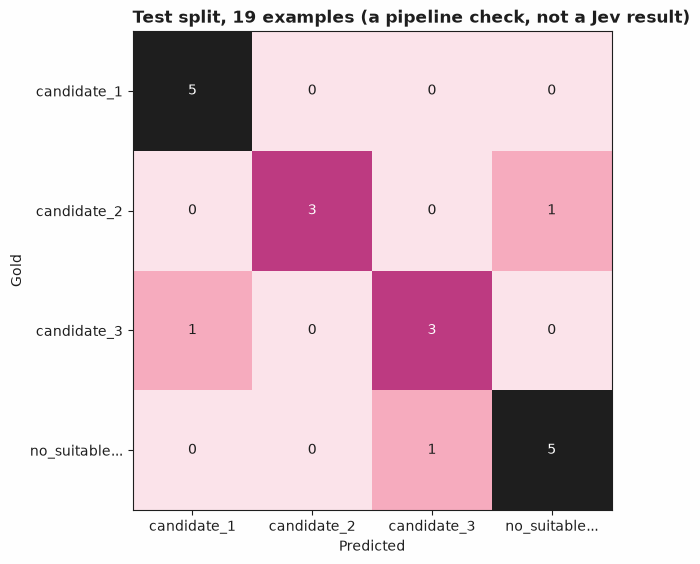

In [9]:
test_examples = select_split(examples, "test")
test_answers = [decide(e) for e in test_examples]
test_gold = [labels[e.id] for e in test_examples]

test_results, test_counts = report(test_examples, test_answers, threshold)
print(f"test, {len(test_examples)} examples, confidence gate {threshold:.4f} frozen{check}")
print(f"top-1 accuracy of the choice: {accuracy(test_gold, test_answers):.4f}{check}")
print(
    f"accepted: {test_counts[helpers.ACCEPTED]}, review: {test_counts[helpers.REVIEW]}, "
    f"kept_original: {test_counts[helpers.KEPT_ORIGINAL]} (of {len(test_examples)}){check}"
)

# Derived, not hand-counted: every test item whose raw stored choice differs from its gold
# label, with the confidence that choice actually carried.
test_wrong = [
    (e.id, a.choice, round(a.confidence, 4), g)
    for e, a, g in zip(test_examples, test_answers, test_gold, strict=True)
    if a.choice != g
]
print(f"wrong on test (stored choice != gold), listed individually{check}:")
for item_id, choice, confidence, gold in test_wrong:
    print(f"  {item_id}: stored {choice} at confidence {confidence} (gold {gold})")

matrix = confusion_matrix(test_gold, test_answers, labels=list(helpers.OPTIONS))
plot_confusion_matrix(matrix, title=f"Test split, {len(test_examples)} examples{check}")

The three items listed above are wrong, in three different ways. `t07-sympathetic-wrong` has gold `candidate_3` (the genuinely sympathetic rewrite), but the stored answer names `candidate_1` instead -- correct meaning, flat tone -- at a confidence comfortably above the frozen gate (0.28): a real, wrong candidate the confidence gate lets straight through, because the gate only protects against *low* confidence, not against being confidently wrong. `t12-courtesy-credit-wrong` has gold `candidate_2` (a genuinely warm rewrite existed), but the stored answer names `no_suitable_rewrite` instead, at a confidence *below* the gate -- and it is still not caught, because `select_rewrite` never runs `no_suitable_rewrite` past the confidence gate at all: the mistake here is not a gate failing to catch a low-confidence wrong answer, it is a wrong answer in a branch that has no gate to fail, confident or not. `t19-setup-fee-wrong` has gold `no_suitable_rewrite` (every candidate is flawed, one by a quietly added restriction), and the stored answer names `candidate_3` instead, but at the lowest confidence of the three, below the gate, so this one *is* caught, and sent to `review` rather than reported. That spread -- one wrong answer the gate catches, one it does not, and one the gate was never asked about -- is the point of the outcome summary two cells down. Counting `v06-sympathetic-wrong` from `validation` above, the fixture set carries four wrong stored answers in total, not an arbitrary "several." 

`per_class_metrics` reports, for every option, **precision** (of the items the raw choice named this option, the fraction that were actually right), **recall** (of the items truly labelled this option, the fraction the raw choice actually named), and **f1**, the harmonic mean of the two: a single number that is low whenever either one is, rather than a plain average a very high precision could paper over a very low recall with. **support** is how many `test` items actually carry that gold label, so a recall figure is only as meaningful as its support is large.

In [10]:
per_class = per_class_metrics(test_gold, test_answers, labels=list(helpers.OPTIONS))
for label, counts in per_class.items():
    print(
        f"{label:20s} precision {counts.precision:.3f}  recall {counts.recall:.3f}  "
        f"f1 {counts.f1:.3f}  support {counts.support}{check}"
    )
nsr_metrics = per_class[helpers.NO_SUITABLE_REWRITE]
print()
print(
    f"no_suitable_rewrite precision {nsr_metrics.precision:.4f}, recall {nsr_metrics.recall:.4f}"
    f"{check}"
)

candidate_1          precision 0.833  recall 1.000  f1 0.909  support 5 (a pipeline check, not a Jev result)
candidate_2          precision 1.000  recall 0.750  f1 0.857  support 4 (a pipeline check, not a Jev result)
candidate_3          precision 0.750  recall 0.750  f1 0.750  support 4 (a pipeline check, not a Jev result)
no_suitable_rewrite  precision 0.833  recall 0.833  f1 0.833  support 6 (a pipeline check, not a Jev result)

no_suitable_rewrite precision 0.8333, recall 0.8333 (a pipeline check, not a Jev result)


`candidate_2` and `candidate_3` each have `support` 4 here, so their recall figures are each one or two items, not a stable rate.

`no_suitable_rewrite`'s precision (0.8333) is 5 of the 6 items the raw choice named `no_suitable_rewrite` that truly had no good candidate: the sixth is `t12-courtesy-credit-wrong` above, where the stored answer names `no_suitable_rewrite` instead of the real `candidate_2` item it actually is. Its recall (0.8333) is 5 of the 6 `test` items truly best served by keeping the original sentence: the sixth is `t19-setup-fee-wrong` above, where the stored answer names `candidate_3` instead -- at low confidence, so it is reviewed rather than reported, but it still costs `no_suitable_rewrite` its recall on this one item, independently of what happens to it afterwards.

`select_rewrite`'s own outcomes, not a confidence threshold reapplied from scratch, are what the next two cells summarize. **Coverage** is the fraction of items the rule actually answered -- `accepted` or `kept_original`, either one a real result handed back -- rather than held for `review`. Among those answered, **accuracy** is the fraction that are right, and **risk** is its complement, `1 - accuracy`, the fraction of answered items that are wrong despite the rule having delivered a result for them. `jev_cookbook.evaluation.evaluate_outcomes(accepted, correct)` computes exactly this from the rule's own `accepted`/`review` split, which is why it is used here instead of `evaluate_selective` (confidence-only): `select_rewrite`'s `no_suitable_rewrite` branch is never gated on confidence at all, so a rule's `accepted` set need not equal "confidence >= gate" -- the next section shows a case on `test` where it genuinely does not.

In [11]:
val_accepted = [r.outcome != helpers.REVIEW for r in val_results]
val_correct = [a.choice == g for a, g in zip(val_answers, val_gold, strict=True)]
val_outcomes = evaluate_outcomes(val_accepted, val_correct)
print(
    f"validation: answered {val_outcomes.n_answered} of {val_outcomes.n_total} "
    f"(coverage {val_outcomes.coverage:.4f}){selection}{check}"
)
print(f"accuracy among those answered: {val_outcomes.accuracy:.4f}{selection}{check}")
print(f"risk among those answered: {val_outcomes.risk:.4f}{selection}{check}")

test_accepted = [r.outcome != helpers.REVIEW for r in test_results]
test_correct = [a.choice == g for a, g in zip(test_answers, test_gold, strict=True)]
test_outcomes = evaluate_outcomes(test_accepted, test_correct)
print()
print(
    f"test: answered {test_outcomes.n_answered} of {test_outcomes.n_total} "
    f"(coverage {test_outcomes.coverage:.4f}){check}"
)
print(f"accuracy among those answered: {test_outcomes.accuracy:.4f}{check}")
print(f"risk among those answered: {test_outcomes.risk:.4f}{check}")

validation: answered 16 of 19 (coverage 0.8421) (a selection step, not a reported result) (a pipeline check, not a Jev result)
accuracy among those answered: 1.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
risk among those answered: 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)

test: answered 16 of 19 (coverage 0.8421) (a pipeline check, not a Jev result)
accuracy among those answered: 0.8750 (a pipeline check, not a Jev result)
risk among those answered: 0.1250 (a pipeline check, not a Jev result)


`validation`'s risk is 0.0000: the only wrong answer in `validation`, `v06-sympathetic-wrong`, is reviewed rather than answered, so nothing wrong is ever reported there -- that is what choosing the confidence gate on `validation` is supposed to buy, and it does, on this split; its coverage, 0.8421 (16 of 19), is not 1.0, so this is a real, non-vacuous selection: three items were actually routed to review to get there, not zero. `test`'s risk is not zero, at 0.1250: 14 of the 16 answered items are right. The two wrong, answered items are `t07-sympathetic-wrong` (a confident wrong candidate the gate let through) and `t12-courtesy-credit-wrong` (a low-confidence wrong `no_suitable_rewrite` the gate was never asked about, confident or not); `t19-setup-fee-wrong`, the third error, is not among them, because it was reviewed rather than answered. A confidence gate chosen to be perfectly accurate on `validation` says nothing about any item this recipe has not seen, which is exactly what `test`'s non-zero risk shows.

**Does `evaluate_outcomes` actually differ from `evaluate_selective` here, or is the distinction only theoretical?** `docs/evaluation.md` says a rule whose `accepted` set is not simply "confidence >= gate" *can* disagree with `evaluate_selective`; it does not promise that it always will on any given fixture set. The cell below checks both, on both splits, rather than asserting the difference and moving on.

In [12]:
val_confidence = [a.confidence for a in val_answers]
val_selective = evaluate_selective(val_correct, val_confidence, threshold)
test_confidence = [a.confidence for a in test_answers]
test_selective = evaluate_selective(test_correct, test_confidence, threshold)

print(
    f"validation evaluate_outcomes : coverage {val_outcomes.coverage:.4f}, "
    f"accuracy {val_outcomes.accuracy:.4f}, risk {val_outcomes.risk:.4f}{selection}{check}"
)
print(
    f"validation evaluate_selective: coverage {val_selective.coverage:.4f}, "
    f"accuracy {val_selective.accuracy:.4f}, risk {val_selective.risk:.4f}{selection}{check}"
)
print()
print(
    f"test       evaluate_outcomes : coverage {test_outcomes.coverage:.4f}, "
    f"accuracy {test_outcomes.accuracy:.4f}, risk {test_outcomes.risk:.4f}{check}"
)
print(
    f"test       evaluate_selective: coverage {test_selective.coverage:.4f}, "
    f"accuracy {test_selective.accuracy:.4f}, risk {test_selective.risk:.4f}{check}"
)

# Where the two disagree about whether an item was "answered" at all.
disagreements = [
    e.id
    for e, accepted, conf in zip(test_examples, test_accepted, test_confidence, strict=True)
    if accepted != (conf >= threshold)
]
print()
print(
    f'test items where the rule\'s own outcome and "confidence >= gate" disagree: {disagreements}{check}'
)

validation evaluate_outcomes : coverage 0.8421, accuracy 1.0000, risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
validation evaluate_selective: coverage 0.8421, accuracy 1.0000, risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)

test       evaluate_outcomes : coverage 0.8421, accuracy 0.8750, risk 0.1250 (a pipeline check, not a Jev result)
test       evaluate_selective: coverage 0.7895, accuracy 0.9333, risk 0.0667 (a pipeline check, not a Jev result)

test items where the rule's own outcome and "confidence >= gate" disagree: ['t12-courtesy-credit-wrong'] (a pipeline check, not a Jev result)


On `validation` the two coincide exactly (coverage, accuracy and risk all equal): every `no_suitable_rewrite` answer there happens to sit above the gate, so nothing distinguishes "the rule answered it" from "its confidence cleared the gate." On `test` they do not: `t12-courtesy-credit-wrong`'s stored confidence, 0.2267, is *below* the 0.28 gate, so `evaluate_selective` -- which gates every item on confidence, with no exception for `no_suitable_rewrite` -- would exclude it as unanswered, dropping `test`'s coverage to 0.7895 (15 of 19) and its risk to 0.0667. `evaluate_outcomes` reports what `select_rewrite` actually did: it answered this item (`kept_original`, wrong), so it stays in both the numerator and the denominator, at coverage 0.8421 and risk 0.1250. The higher number is the honest one for this rule: a confidence-only accounting would quietly launder away exactly the mistake -- a low-confidence wrong fallback -- that the rule's design lets through unchecked.

**The gate is pinned only up to an empty band.** `select_confidence_threshold` returned 0.2800 because every confidence strictly below it among real-candidate `validation` matches is either `v06-sympathetic-wrong` (0.2667, the one to exclude) or safely correct at much higher confidence; nothing sits strictly between 0.2667 and 0.28, so any cut in that open interval would have worked identically. `v19-admin-access`, correct, sits exactly on the chosen value (confidence 0.2800 from a top probability of 0.46): the inclusive comparison in `select_rewrite` accepts it, but a fixture one digit lower would move it into `review`. The curve below, over the same real-candidate `validation` pool the gate was chosen from, shows what the gate buys and does not buy as it moves.

ungated accuracy (no gate at all): 0.9167 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  gate >= 0.8267: coverage 0.0833, accuracy 1.0000, risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  gate >= 0.8000: coverage 0.2500, accuracy 1.0000, risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  gate >= 0.7867: coverage 0.3333, accuracy 1.0000, risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  gate >= 0.7733: coverage 0.4167, accuracy 1.0000, risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  gate >= 0.7600: coverage 0.5833, accuracy 1.0000, risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  gate >= 0.7333: coverage 0.6667, accuracy 1.0000, risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  gate >= 0.2800: cov

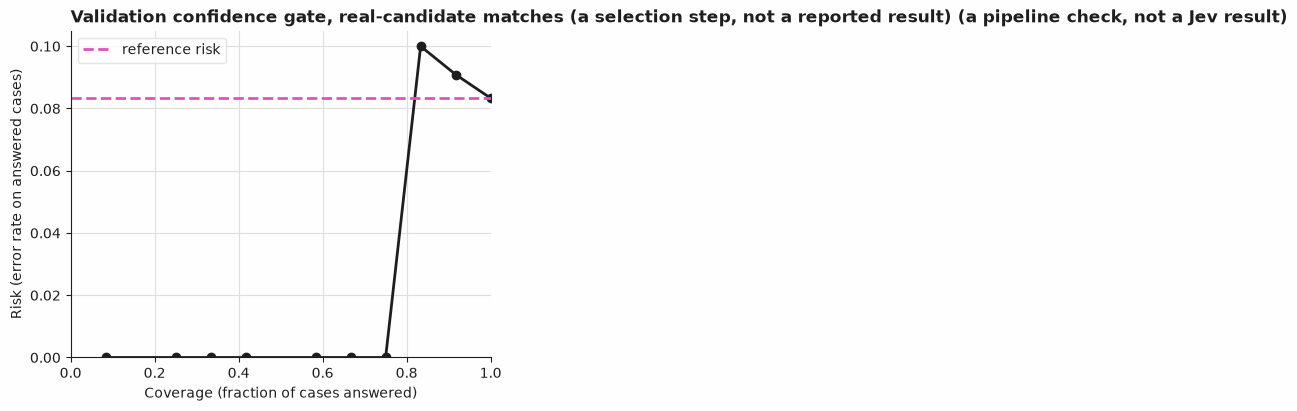

In [13]:
gate_curve = selective_curve(real_correct, real_confidence)
ungated_accuracy = sum(real_correct) / len(real_correct)
print(f"ungated accuracy (no gate at all): {ungated_accuracy:.4f}{selection}{check}")
for t, cov, acc, risk in zip(
    gate_curve.thresholds, gate_curve.coverage, gate_curve.accuracy, gate_curve.risk, strict=True
):
    marker = " <- frozen" if abs(t - threshold) < 1e-9 else ""
    print(
        f"  gate >= {t:.4f}: coverage {cov:.4f}, accuracy {acc:.4f}, risk {risk:.4f}{marker}"
        f"{selection}{check}"
    )
plot_risk_coverage(
    gate_curve,
    reference_risk=1 - ungated_accuracy,
    title=f"Validation confidence gate, real-candidate matches{selection}{check}",
)

Loosening the gate past 0.28 costs accuracy before it helps anything: the very next point, 0.2667, lets `v06-sympathetic-wrong` itself through (accuracy falls to 0.9000 at coverage 0.8333), and only at 0.2000 -- answering every real-candidate match in `validation`, the ungated accuracy of 0.9167 -- does it recover past the frozen gate's 1.0000, because by then it has also picked up the two correct-but-cautious items (`v17-conference-miss`, `v18-policy-effective`) the frozen gate gives up. There is no cut in this pool that is both wider than 0.28 and at least as accurate; 0.28 is the most coverage this `target_accuracy=1.0` objective can buy.

## What was and was not measured

Measured: that the pipeline runs end to end, and that the rule and the evaluation behave as designed on 38 scored items (plus 2 more, shown in this notebook but never scored). Not measured: anything about how Jev performs, how fast it is, or what it costs. The stored answers in the offline run are written by hand as probabilities, four of them wrong on purpose and in different ways (one in `validation` itself, caught by the gate it goes on to define; one in `test` that is wrong and confident through the gate; one in `test` that is wrong and not confident through the un-gated `no_suitable_rewrite` branch; one in `test` that is wrong but caught by the gate), so every number above describes this fixture set and not a model.

In [14]:
if offline:
    print(f"Provenance: {backend.mode}. Not measured live: a pipeline check, not a Jev result.")
else:
    dates = ", ".join(getattr(backend, "recorded_dates", ()) or ()) or "this run"
    print(f"Provenance: {backend.mode}, model {backend.model}")
    print(f"Captured: {dates}")
    print(f"N: {len(val_examples)} validation and {len(test_examples)} test examples")

Provenance: synthetic. Not measured live: a pipeline check, not a Jev result.


## Next steps

- Add a hard item to `ROWS` in `build_fixtures.py` -- a fourth candidate flaw combination, or a position you have not yet tried for the correct rewrite -- with the answer you expect a model might give, run `python build_fixtures.py`, and see where `select_rewrite` sends it.
- Change the confidence gate's target in the "Python's part" cell (`target_accuracy=1.0` to something looser, such as `0.9`) and see how coverage and the review count trade off: loosening it enough to tolerate `v06-sympathetic-wrong` drops the frozen gate and changes which `validation` items are reviewed.
- Neighbouring recipes: [`08-faq-selection`](../08-faq-selection/), a `Choice` over a different fixed candidate set with its own fallback outcome Python never gates on confidence; [`07-word-sense-selection`](../07-word-sense-selection/), choosing among a fixed set of candidate meanings instead of candidate rewrites.